# 04 — UVA / UVB ฟ้าใส (SPECTRL2)

ใช้เฉพาะข้อมูลฝึก `train_merged.parquet` (ปทุมธานี 2023–2025) **ไม่ใช้ TEMIS/OMI**
ฟังก์ชันอยู่ใน `src/physics.py`: `clear_sky_spectrum`, `integrate_band`, `uva_uvb_clear_interval`

**ค่าที่ตั้งไว้**
- **ตัวหารของ CMF_A/CMF_B** ใช้ `aod500 = 0` (ไม่มีฝุ่นละออง) โดยใช้ ozone climatology, ไอน้ำ 4 cm และค่าเฉลี่ยทั้งชั่วโมง (`CMF_SUBSTEPS = 12`) ค่านี้เรียกว่า **แบบ A** ซึ่งผู้ใช้เลือกในวัน 4 เพื่อให้ CMF ทั้งสามตัวมีความหมายเดียวกันคือ "ผลของเมฆ + ฝุ่น" เหมือน CMF_UVI ที่มาจาก Madronich
- **แบบ B** ใช้ AOD จริงจาก Open-Meteo (แปลงจาก 550 เป็น 500 nm ด้วย Ångström α = 1.14 ซึ่งเป็นค่าเริ่มต้นของ SPECTRL2) แสดงไว้เพื่อเปรียบเทียบเท่านั้น
- **Band:** UVA = 315–400 nm, UVB = **300–315 nm** เพราะ SPECTRL2 เริ่มที่ 300 nm แต่ NASA POWER นิยาม UVB เป็น 280–315 nm และในช่วง UVB กริดของ SPECTRL2 มีแค่ **4 จุด** (300, 305, 310, 315 nm)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")


In [2]:
from src.metrics import error_metrics
from src.physics import (CMF_SUBSTEPS, UVA_BAND, UVB_BAND, clear_sky_spectrum, integrate_band,
                         ozone_climatology, spectrl2_wavelengths, uva_uvb_clear_interval, uvi_clear_interval)

df = pd.read_parquet(ROOT / "dataset" / "processed" / "train_merged.parquet")
t = df["time_utc"]
aod500 = df["aerosol_optical_depth"].to_numpy() * (500 / 550) ** -1.14

A = uva_uvb_clear_interval(t, substeps=CMF_SUBSTEPS)                    # default: AOD = 0
B = uva_uvb_clear_interval(t, aod500=aod500, substeps=CMF_SUBSTEPS)    # real AOD (comparison)
df["uva_A"], df["uvb_A"] = A["uva_wm2"].to_numpy(), A["uvb_wm2"].to_numpy()
df["uva_B"], df["uvb_B"] = B["uva_wm2"].to_numpy(), B["uvb_wm2"].to_numpy()
df["uvi_madronich"] = uvi_clear_interval(t, substeps=CMF_SUBSTEPS)

kt = df["nasa_sw_all_wm2"] / df["nasa_sw_clear_wm2"].where(df["nasa_sw_clear_wm2"] > 50)
clear = (df["uvi_madronich"] >= 0.5) & (df["nasa_cloud_pct"] < 10) & (kt > 0.9)
print(len(df), "daytime hours;", int(clear.sum()), "clear hours (same rule as notebook 03)")
wl = spectrl2_wavelengths()
print("UVB grid points:", wl[(wl >= UVB_BAND[0]) & (wl <= UVB_BAND[1])].tolist())

13280 daytime hours; 1680 clear hours (same rule as notebook 03)
UVB grid points: [300.0, 305.0, 310.0, 315.0]


## 1. ตัวอย่างสเปกตรัมตอนเที่ยง (ตรวจหน่วยและรูปร่าง)

UVA A/B: [64.43] [52.6]
UVB A/B: [2.211] [1.694]


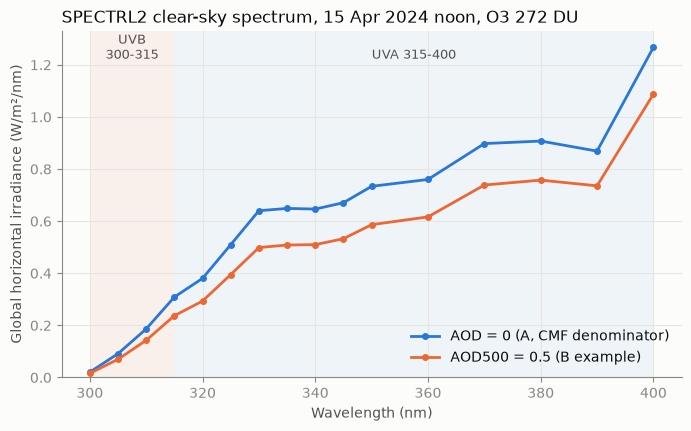

In [3]:
noon = pd.DatetimeIndex(["2024-04-15 05:30"], tz="UTC")
o3 = ozone_climatology(4)
wl, sA = clear_sky_spectrum(noon, ozone_du=o3, aod500=0.0)
_, sB = clear_sky_spectrum(noon, ozone_du=o3, aod500=0.5)
uv = wl <= 400
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axvspan(*UVB_BAND, color=C_NASA, alpha=0.08, lw=0)
ax.axvspan(*UVA_BAND, color=C_OM, alpha=0.06, lw=0)
ax.plot(wl[uv], sA[0, uv], color=C_OM, marker="o", ms=4, label="AOD = 0 (A, CMF denominator)")
ax.plot(wl[uv], sB[0, uv], color=C_NASA, marker="o", ms=4, label="AOD500 = 0.5 (B example)")
ax.text(307.5, ax.get_ylim()[1] * 0.92, "UVB\n300-315", ha="center", color=INK2, fontsize=9)
ax.text(357.5, ax.get_ylim()[1] * 0.92, "UVA 315-400", ha="center", color=INK2, fontsize=9)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Global horizontal irradiance (W/m²/nm)")
ax.set_title(f"SPECTRL2 clear-sky spectrum, 15 Apr 2024 noon, O3 {o3:.0f} DU", loc="left")
ax.set_ylim(0, None)
ax.legend(loc="lower right")
save(fig, "spec_noon_spectrum.png")
print("UVA A/B:", integrate_band(wl, sA, *UVA_BAND).round(2), integrate_band(wl, sB, *UVA_BAND).round(2))
print("UVB A/B:", integrate_band(wl, sA, *UVB_BAND).round(3), integrate_band(wl, sB, *UVB_BAND).round(3))

## 2. เทียบกับ NASA POWER ในชั่วโมงฟ้าเปิด (ตรวจหน่วย W/m²)
ตาราง: `bias` = NASA POWER − SPECTRL2 และ `ratio` = ค่ามัธยฐานของ NASA / SPECTRL2 (สำหรับแบบ A ค่านี้คือ CMF ของชั่วโมงฟ้าเปิดนั่นเอง)

In [4]:
rows = []
for band, nasa in [("UVA", "nasa_uva_wm2"), ("UVB", "nasa_uvb_wm2")]:
    for variant in ["A", "B"]:
        col = f"{band.lower()}_{variant}"
        m = error_metrics(df.loc[clear, nasa], df.loc[clear, col])
        ratio = (df.loc[clear, nasa] / df.loc[clear, col]).median()
        rows.append({"band": band, "variant": "A: AOD=0" if variant == "A" else "B: real AOD",
                     **m, "ratio NASA/SPECTRL2": ratio})
m = error_metrics(df.loc[clear, "nasa_uvi"], df.loc[clear, "uvi_madronich"])
rows.append({"band": "UVI (day 3)", "variant": "Madronich", **m,
             "ratio NASA/SPECTRL2": (df.loc[clear, "nasa_uvi"] / df.loc[clear, "uvi_madronich"]).median()})
clear_table = pd.DataFrame(rows)
clear_table.round(3)

,band,variant,n,mae,bias,rmse,r,ratio NASA/SPECTRL2
0,UVA,A: AOD=0,1680,5.707,-5.707,6.807,0.967,0.866
1,UVA,B: real AOD,1680,3.747,3.534,4.572,0.981,1.104
2,UVB,A: AOD=0,1680,0.170,-0.167,0.223,0.973,0.846
3,UVB,B: real AOD,1680,0.133,0.121,0.179,0.984,1.109
4,UVI (day 3),Madronich,1680,1.886,-1.886,2.218,0.971,0.720


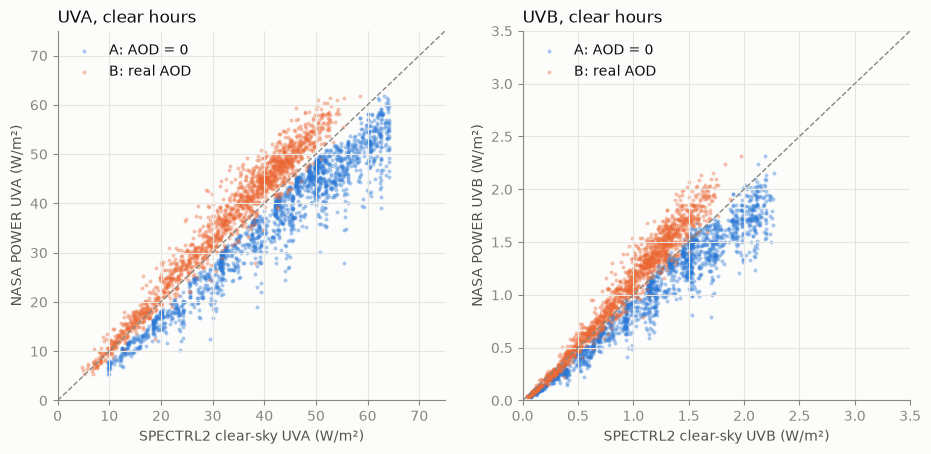

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, band, nasa, lim in [(axes[0], "uva", "nasa_uva_wm2", 75), (axes[1], "uvb", "nasa_uvb_wm2", 3.5)]:
    ax.scatter(df.loc[clear, f"{band}_A"], df.loc[clear, nasa], s=8, color=C_OM, alpha=0.4, lw=0, label="A: AOD = 0")
    ax.scatter(df.loc[clear, f"{band}_B"], df.loc[clear, nasa], s=8, color=C_NASA, alpha=0.4, lw=0, label="B: real AOD")
    ax.plot([0, lim], [0, lim], color=MUTED, lw=1, ls="--")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(f"SPECTRL2 clear-sky {band.upper()} (W/m²)")
    ax.set_ylabel(f"NASA POWER {band.upper()} (W/m²)")
    ax.set_title(f"{band.upper()}, clear hours", loc="left")
    ax.legend(loc="upper left")
save(fig, "spec_vs_nasa_clear.png")

## 3. อัตราส่วน NASA / SPECTRL2 ตาม AOD
- **แบบ A:** ถ้าอัตราส่วนลดลงเมื่อ AOD เพิ่ม แสดงว่า CMF_A/CMF_B รวมผลของฝุ่นละอองเหมือน CMF_UVI (สอดคล้องกันตามที่ตั้งใจ)
- **แบบ B:** ถ้าอัตราส่วนแทบไม่เปลี่ยนตาม AOD แสดงว่าโมเดล aerosol ของ SPECTRL2 อธิบายผลของฝุ่นได้

,UVA A,UVA B,UVB A,UVB B,UVI Madronich
AOD quartile,,,,,
"(0.059, 0.24]",0.935,1.076,0.933,1.081,0.801
"(0.24, 0.39]",0.891,1.099,0.878,1.099,0.749
"(0.39, 0.57]",0.850,1.116,0.821,1.111,0.699
"(0.57, 1.62]",0.800,1.160,0.769,1.170,0.658


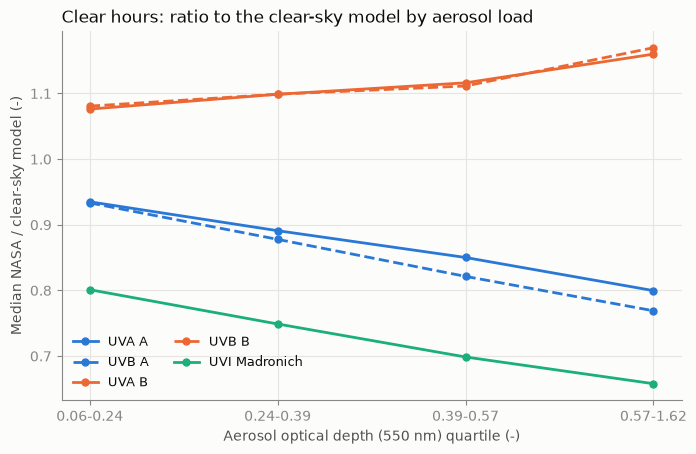

In [6]:
c = df[clear].copy()
c["AOD quartile"] = pd.qcut(c["aerosol_optical_depth"], 4)
ratios = pd.DataFrame({
    "UVA A": c["nasa_uva_wm2"] / c["uva_A"], "UVA B": c["nasa_uva_wm2"] / c["uva_B"],
    "UVB A": c["nasa_uvb_wm2"] / c["uvb_A"], "UVB B": c["nasa_uvb_wm2"] / c["uvb_B"],
    "UVI Madronich": c["nasa_uvi"] / c["uvi_madronich"], "AOD quartile": c["AOD quartile"],
}).groupby("AOD quartile", observed=True).median()

fig, ax = plt.subplots(figsize=(8, 4.8))
x = np.arange(len(ratios))
labels = [f"{iv.left:.2f}-{iv.right:.2f}" for iv in ratios.index]
for col, color, ls in [("UVA A", C_OM, "-"), ("UVB A", C_OM, "--"), ("UVA B", C_NASA, "-"),
                       ("UVB B", C_NASA, "--"), ("UVI Madronich", C_THIRD, "-")]:
    ax.plot(x, ratios[col], color=color, ls=ls, marker="o", ms=5, label=col)
ax.set_xticks(x, labels)
ax.set_xlabel("Aerosol optical depth (550 nm) quartile (-)")
ax.set_ylabel("Median NASA / clear-sky model (-)")
ax.set_title("Clear hours: ratio to the clear-sky model by aerosol load", loc="left")
ax.legend(loc="lower left", ncols=2, fontsize=9)
save(fig, "spec_ratio_by_aod.png")
ratios.round(3)

## 4. Sensitivity: ไอน้ำ และ โอโซน (แบบ A, ชั่วโมงกลางวันที่ UVI ฟ้าใส ≥ 0.5)

In [7]:
use = df["uvi_madronich"] >= 0.5
sub = df[use].sample(2000, random_state=42).sort_values("time_utc")
ts = sub["time_utc"]
base = uva_uvb_clear_interval(ts, substeps=1)
out = []
for name, kw in [("PW 1 cm", {"pw_cm": 1.0}), ("PW 6 cm", {"pw_cm": 6.0}),
                 ("O3 = NASA TO3", {"ozone_du": sub["nasa_ozone_du"].to_numpy()}),
                 ("O3 = 300 DU", {"ozone_du": 300.0})]:
    alt = uva_uvb_clear_interval(ts, substeps=1, **kw)
    for band in ["uva_wm2", "uvb_wm2"]:
        pct = (alt[band] - base[band]) / base[band] * 100
        out.append({"change vs default (PW 4 cm, climatology O3)": name, "band": band[:3].upper(),
                    "mean %": pct.mean(), "mean |%|": pct.abs().mean(), "max |%|": pct.abs().max()})
pd.DataFrame(out).round(2)

,"change vs default (PW 4 cm, climatology O3)",band,mean %,mean |%|,max |%|
0,PW 1 cm,UVA,0.00,0.00,0.00
1,PW 1 cm,UVB,0.00,0.00,0.00
2,PW 6 cm,UVA,0.00,0.00,0.00
3,PW 6 cm,UVB,0.00,0.00,0.00
4,O3 = NASA TO3,UVA,0.01,0.05,0.39
5,O3 = NASA TO3,UVB,0.26,1.90,14.77
6,O3 = 300 DU,UVA,-0.37,0.37,0.99
7,O3 = 300 DU,UVB,-13.87,13.87,33.59


## สรุปผล

In [8]:
print(clear_table[["band", "variant", "n", "mae", "bias", "r", "ratio NASA/SPECTRL2"]].round(3).to_string(index=False))
print()
print(ratios.round(3).to_string())

       band     variant    n   mae   bias     r  ratio NASA/SPECTRL2
        UVA    A: AOD=0 1680 5.707 -5.707 0.967                0.866
        UVA B: real AOD 1680 3.747  3.534 0.981                1.104
        UVB    A: AOD=0 1680 0.170 -0.167 0.973                0.846
        UVB B: real AOD 1680 0.133  0.121 0.984                1.109
UVI (day 3)   Madronich 1680 1.886 -1.886 0.971                0.720

               UVA A  UVA B  UVB A  UVB B  UVI Madronich
AOD quartile                                            
(0.059, 0.24]  0.935  1.076  0.933  1.081          0.801
(0.24, 0.39]   0.891  1.099  0.878  1.099          0.749
(0.39, 0.57]   0.850  1.116  0.821  1.111          0.699
(0.57, 1.62]   0.800  1.160  0.769  1.170          0.658


### ข้อสรุป (ข้อมูลฝึก 2023–2025 ชั่วโมงฟ้าเปิด n = 1,680)
1. **หน่วยตรงกัน (W/m²):** NASA POWER UVA/UVB ต่างจาก SPECTRL2 ไม่เกินราว 10–15% และ r ≈ 0.97–0.98 ยืนยันว่าการแปลง Wh/m² ต่อชั่วโมงเป็น W/m² ในวัน 1–2 ถูกต้อง
2. **แบบ A (AOD = 0, ค่าเริ่มต้น):** NASA/SPECTRL2 ≈ 0.87 (UVA) และ 0.85 (UVB) และลดลงเมื่อ AOD เพิ่ม (0.93 → 0.80 สำหรับ UVA, 0.93 → 0.77 สำหรับ UVB) **เป็นแพทเทิร์นเดียวกับ CMF_UVI** (0.80 → 0.66) CMF ทั้งสามตัวจึงมีความหมายเดียวกันคือ "เมฆ + ฝุ่น" ตามที่ตั้งใจ แต่ระดับในวันฟ้าเปิดไม่เท่ากัน (UVI ≈ 0.72, UVA/UVB ≈ 0.85) เพราะ Madronich ให้ค่าสูงกว่า SPECTRL2 เมื่อเทียบกับ NASA ซึ่งไม่เป็นปัญหา เพราะแต่ละ target ใช้ตัวหารเดียวกันทั้งตอนฝึกและตอนใช้งาน
3. **แบบ B (AOD จริง):** อัตราส่วนกลายเป็น ≈ 1.10 และ**เพิ่มขึ้น**ตาม AOD (1.08 → 1.17) แปลว่า SPECTRL2 + AOD ของ CAMS ลด UV มากเกินไปเมื่อฝุ่นหนา ถ้าใช้แบบ B ตัวหารจะมี bias ที่ขึ้นกับความแม่นของ AOD พยากรณ์ด้วย เป็นอีกเหตุผลที่แบบ A เหมาะกว่า
4. **ไอน้ำ:** ไม่มีผลต่อ UVA/UVB เลย (0.00%) เพราะแถบดูดกลืนของน้ำอยู่นอกช่วง UV ค่าคงที่ 4 cm จึงใช้ได้
5. **โอโซน:** ส่งผลกับ UVB เป็นหลัก climatology ต่างจาก TO3 จริงเฉลี่ย 1.9% (สูงสุด 15%) ส่วน 300 DU ทำให้ UVB ต่ำ 13.9% UVA แทบไม่เปลี่ยน (< 1%)
6. **ข้อจำกัดเรื่อง UVB:** SPECTRL2 เริ่มที่ 300 nm จึงได้แค่ 300–315 nm และมี**แค่ 4 จุด** (300, 305, 310, 315) อินทิเกรตแบบ trapezoid บนกริด 5 nm ส่วน NASA POWER นิยาม UVB เป็น 280–315 nm อย่างไรก็ตาม อัตราส่วนของ UVB (0.85) ใกล้กับ UVA (0.87) แปลว่าส่วน 280–300 nm ที่ขาดไปมีผลน้อยต่อ W/m² (แสงช่วงนี้ถูกโอโซนดูดกลืนเกือบหมด) แต่ความผิดพลาดของการอินทิเกรตบนกริดหยาบยังประเมินตรงไม่ได้ ต้องเขียนเป็นข้อจำกัดในรายงาน
